In [1]:
import torch, torchvision # pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
from sklearn.model_selection import train_test_split, GroupKFold, StratifiedKFold, KFold

from PIL import Image
import matplotlib.pyplot as plt
import cv2, os, shutil, glob, json, math, datetime, random, gc, ast
import numpy as np
import pandas as pd
import torch.nn as nn
import seaborn as sns
from time import time
from utils.index import *
from tqdm import tqdm

from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.ops import nms

from torch.utils.data import DataLoader, Dataset
from torch.utils.data.sampler import SequentialSampler

from utils.Plotter.index import Plotter
pd.set_option('display.max_columns', None)

In [2]:
# MEMÓRIA DA GPU EM SEGMENTOS EXPANSÍVEIS (MENOS FRAGMENTAÇÃO NAS REDES GRANDES NO TILE 4×256×256); SÓ VALE ANTES DA PRIMEIRA ALOCAÇÃO
os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

gc.collect()
print(torch.__version__)              # versão do PyTorch
print(torch.cuda.is_available())      # True se detectou a GPU
print(torch.cuda.get_device_name(0))  # nome da GPU

2.7.1+cu128
True
NVIDIA GeForce RTX 5070


In [3]:
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    np.random.default_rng(seed=seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print('random seed done')


OPTIONS = json.loads(open('../Task/info.json', 'r').read())
TRIAL   = OPTIONS.get('trial', 0)

seed_everything(42 + TRIAL)
OPTIONS

random seed done


{'network': 'dbrnet',
 'dataset': 'facies',
 'img_size': [4, 256, 256],
 'step': 3,
 'scaling': 'percentile',
 'multiclass': True,
 'lr': 0.0001,
 'loss': 'dice_focal',
 'batch_size': 2,
 'scheduler': 'plateau',
 'dropout': 0.05,
 'num_filters': 32,
 'ema': True,
 'amp': True,
 'epochs': 200,
 'patience': 20,
 'n_trials': 1,
 'trial': 0}

In [4]:
if OPTIONS.get('network') == 'macnn':
    torch.backends.cudnn.deterministic = False

IMG_SIZE   = OPTIONS.get('img_size')
BATCH_SIZE = OPTIONS.get('batch_size')
IMG_SIZE, BATCH_SIZE

([4, 256, 256], 2)

In [ ]:
import sys
sys.path.append('..')
from Dataset.index import Normalization

DATABASE = f'../Dataset/{OPTIONS.get("dataset")}/DataBase.csv'
df       = pd.read_csv(DATABASE)
IMG_SIZE = ast.literal_eval(df['shape'].iloc[0])
STEP     = int(df['step'].iloc[0])

# O DataBase.csv TEM DE ESTAR NO ESCALONAMENTO QUE A RODADA PEDE (SEM A COLUNA, É O 'percentile', O VOLUME COMO VEM)
SCALING   = OPTIONS.get('scaling', Normalization.DEFAULT)
FORMATTED = Normalization.read(DATABASE)

if FORMATTED != SCALING:
    raise ValueError(f'{DATABASE} está com scaling={FORMATTED!r} e a rodada pede scaling={SCALING!r}: rode o Format do dataset com este info.json')

print(f'{DATABASE}: {len(df)} tiles de shape {IMG_SIZE}, step {STEP}')
print(df.img_path.iloc[0])
df

../Dataset/facies/DataBase.csv: 7074 tiles de shape (4, 256, 256), step 3
/home/grva-mintcave/Projects/Facies/Dataset/facies/tiles/images/img_00000.npy


,img_path,mask_path,shape,min,max,mean,std,msk_max,step,scaling
0,/home/grva-mintcave/Projects/Facies/Dataset/fa...,/home/grva-mintcave/Projects/Facies/Dataset/fa...,"(4, 256, 256)",0.229268,0.778868,0.502732,0.037087,3,3,percentile
1,/home/grva-mintcave/Projects/Facies/Dataset/fa...,/home/grva-mintcave/Projects/Facies/Dataset/fa...,"(4, 256, 256)",0.000000,0.937083,0.502533,0.038899,4,3,percentile
2,/home/grva-mintcave/Projects/Facies/Dataset/fa...,/home/grva-mintcave/Projects/Facies/Dataset/fa...,"(4, 256, 256)",0.000000,1.000000,0.502285,0.046293,4,3,percentile
3,/home/grva-mintcave/Projects/Facies/Dataset/fa...,/home/grva-mintcave/Projects/Facies/Dataset/fa...,"(4, 256, 256)",0.357488,0.732417,0.502492,0.019550,4,3,percentile
4,/home/grva-mintcave/Projects/Facies/Dataset/fa...,/home/grva-mintcave/Projects/Facies/Dataset/fa...,"(4, 256, 256)",0.000000,1.000000,0.501868,0.083783,4,3,percentile
...,...,...,...,...,...,...,...,...,...,...
7069,/home/grva-mintcave/Projects/Facies/Dataset/fa...,/home/grva-mintcave/Projects/Facies/Dataset/fa...,"(4, 256, 256)",0.000000,1.000000,0.497164,0.248731,5,3,percentile
7070,/home/grva-mintcave/Projects/Facies/Dataset/fa...,/home/grva-mintcave/Projects/Facies/Dataset/fa...,"(4, 256, 256)",0.000000,1.000000,0.491530,0.283405,5,3,percentile
7071,/home/grva-mintcave/Projects/Facies/Dataset/fa...,/home/grva-mintcave/Projects/Facies/Dataset/fa...,"(4, 256, 256)",0.000000,1.000000,0.500084,0.218975,5,3,percentile
7072,/home/grva-mintcave/Projects/Facies/Dataset/fa...,/home/grva-mintcave/Projects/Facies/Dataset/fa...,"(4, 256, 256)",0.000000,1.000000,0.499803,0.119612,5,3,percentile


In [6]:
MULTICLASS = True
classes    = int(df['msk_max'].max()) + 1
classes

6

img: (np.float32(0.22926785), np.float32(0.7788685))
msk: (np.uint8(0), np.uint8(3))


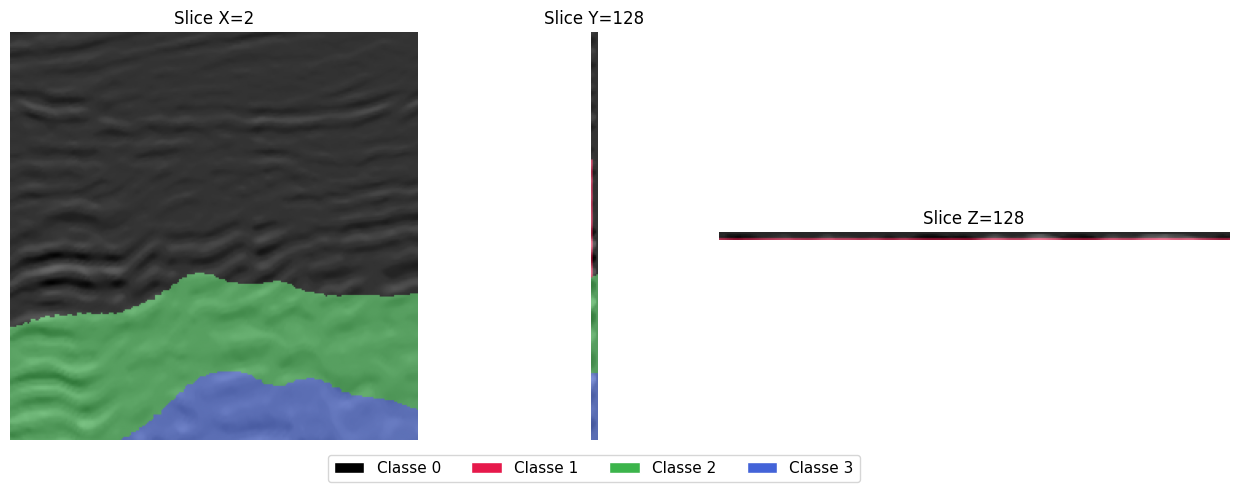

img: (np.float32(0.0), np.float32(0.9370833))
msk: (np.uint8(0), np.uint8(4))


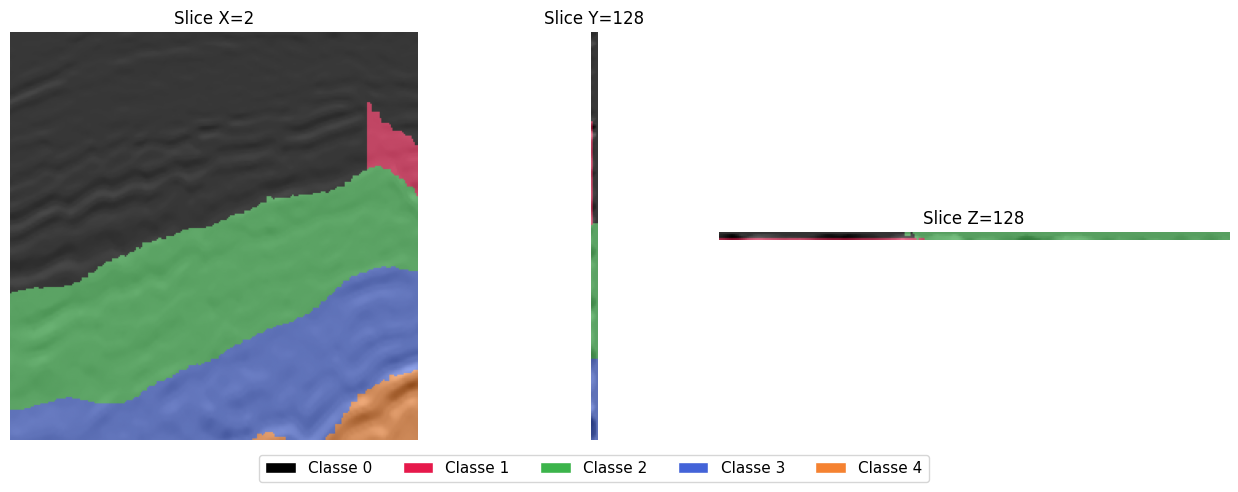

img: (np.float32(0.0), np.float32(1.0))
msk: (np.uint8(0), np.uint8(4))


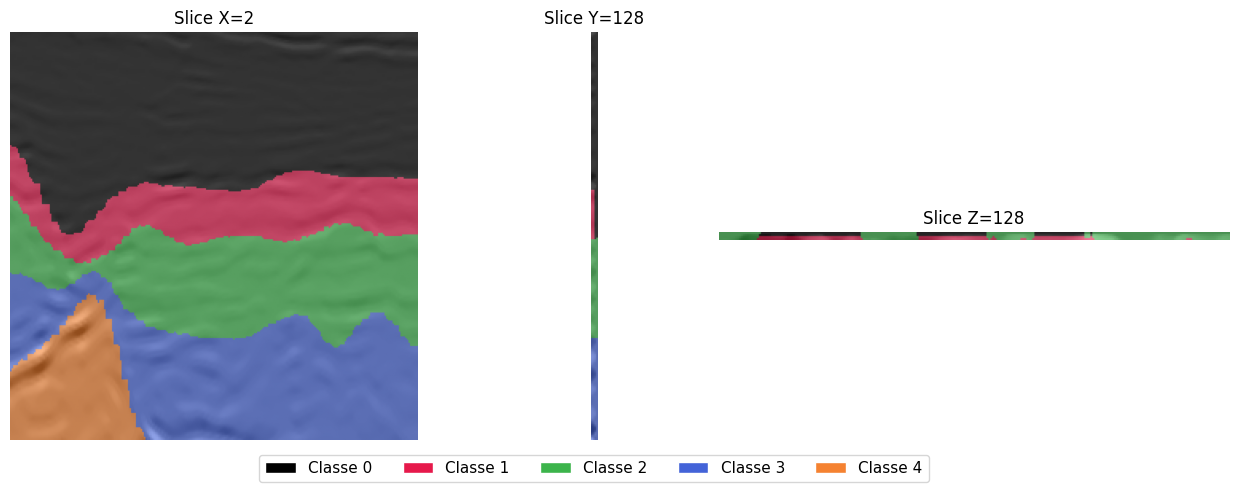

In [7]:
for index in range(3):
    img, msk = np.load(df.iloc[index].img_path), np.load(df.iloc[index].mask_path)
    print(f'img: {np.min(img), np.max(img)}')
    print(f'msk: {np.min(msk), np.max(msk)}')
    showTile(img=img, mask=msk)

# SPLITS DOS DADOS

- O teste sai primeiro, com o mesmo `train_test_split(test_size, random_state=42)` do `1 - Model`: o `3 - Predict` refaz o mesmo split e acha os mesmos tiles.
- O resto é dividido em `K_FOLD` dobras; cada dobra valida numa parte e treina nas outras. Os tiles de teste nunca entram em nenhuma dobra.
- O split vai para o `division` do `info.json` salvo (`k_fold`, `val_size`, `test_size`, o `step` do `Format` e o `n_images` da melhor dobra); o `processing` fica sendo o `Task/info.json` exatamente como veio.

In [8]:
K_FOLD    = 5
TEST_SIZE = 0.1
VAL_SIZE  = 1 / K_FOLD

In [9]:
temp_df, test_df = train_test_split(df, test_size=TEST_SIZE, random_state=42)
folds = [(temp_df.iloc[train], temp_df.iloc[val]) for train, val in KFold(n_splits=K_FOLD, shuffle=True, random_state=42).split(temp_df)]

DIVISION = {'k_fold': K_FOLD, 'val_size': VAL_SIZE, 'test_size': TEST_SIZE, 'step': STEP}

print('tiles de teste dentro das dobras:', len(set(test_df.img_path) & set(temp_df.img_path)))
pd.DataFrame([{'fold': fold, 'train': len(train_df), 'val': len(val_df), 'test': len(test_df)} for fold, (train_df, val_df) in enumerate(folds)])

tiles de teste dentro das dobras: 0


,fold,train,val,test
0,0,5092,1274,708
1,1,5093,1273,708
2,2,5093,1273,708
3,3,5093,1273,708
4,4,5093,1273,708


# AUMENTAÇÃO

- O `augmentations` do `info.json` liga a aumentação do treino (`Transforms/index.py`); `null` ou ausente treina com os tiles como estão, igual a antes.
- O sorteio é feito no `DataLoader`, tile a tile e de novo a cada época, com a semente `(42 + trial, época, índice)`: o mesmo treino repete a mesma aumentação com qualquer número de workers, sem tocar no gerador global (o `shuffle` e os pesos iniciais não mudam).
- `n_aug` (1, como nos autores) é quantas variações de cada tile entram por época: a época passa a ter `n_aug` × tiles amostras, cada uma com o seu sorteio.
- As operações rodam na ordem em que aparecem no JSON e só no treino; validação e teste ficam como estão.
- Com `crop`, a rede é montada na janela do recorte e prediz o tile inteiro de validação e teste por janela deslizante (`overlap`, `mode`, lote de `batch_size` janelas): o IoU continua sendo do tile inteiro. O `img_size` do modelo salvo é a janela, que o `3 - Predict` já usa.
- Nas facies o rótulo é a classe: a máscara segue a imagem pelo vizinho mais próximo, a borda da rotação e da suavização espelha o tile e o `crop` centra numa classe sorteada por igual entre as do tile.
- Os eixos do config são `(inline, z, xline)`: `flip` em `[0, 2]` é o espelho horizontal; o `rotate90` exige plano quadrado (no tile de 4 inlines o horizontal `[0, 2]` não é) e nada deve virar o `z`, que inverteria a estratigrafia.
- Cada dobra tem o seu dataset de treino, com o contador de época próprio: a dobra 3 sorteia o mesmo que sortearia rodando sozinha.

In [10]:
from Transforms.index import Transforms

In [11]:
transforms = Transforms(OPTIONS.get('augmentations'), seed=42 + TRIAL, batch=BATCH_SIZE)
WINDOW    = transforms.window or IMG_SIZE

print(f'tile {IMG_SIZE} | janela da rede {WINDOW} | n_aug {transforms.copies}')
pd.DataFrame(transforms.options).T.fillna('')

tile (4, 256, 256) | janela da rede (4, 256, 256) | n_aug 1


""


# MODELO

In [12]:
from Network.index import ModelNetwork

In [13]:
model_options = {
    'network': OPTIONS.get('network'),
    'img_size': WINDOW,
    'classes': classes,
    'channels': 1,
    'dropout': OPTIONS.get('dropout'),
    'num_filters': OPTIONS.get('num_filters'),
    'lr': OPTIONS.get('lr'),
    'deep_supervision': OPTIONS.get('deep_supervision', False),
}

print(model_options)
network = ModelNetwork(**model_options)
network.model

{'network': 'dbrnet', 'img_size': (4, 256, 256), 'classes': 6, 'channels': 1, 'dropout': 0.05, 'num_filters': 32, 'lr': 0.0001, 'deep_supervision': False}


Unet3D_V2(
  (enc1): EncoderBlock(
    (conv_block): Conv3DBlock(
      (conv1): Conv3d(1, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
      (norm1): GroupNorm(8, 32, eps=1e-05, affine=True)
      (act1): LeakyReLU(negative_slope=0.1, inplace=True)
      (conv2): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
      (norm2): GroupNorm(8, 32, eps=1e-05, affine=True)
      (act2): LeakyReLU(negative_slope=0.1, inplace=True)
    )
    (pool): MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2), padding=0, dilation=1, ceil_mode=False)
    (dropout): Dropout3d(p=0.0125, inplace=False)
  )
  (enc2): EncoderBlock(
    (conv_block): Conv3DBlock(
      (conv1): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
      (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
      (act1): LeakyReLU(negative_slope=0.1, inplace=True)
      (conv2): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1)

In [14]:
network.classes

6

# DATASET

In [15]:
from torch.utils.data import Dataset

In [16]:
class CustomDataset(Dataset):
    def __init__(self, df, multiclass=False, transforms=None):
        self.df = df.reset_index(drop=True)
        self.multiclass = multiclass
        self.transforms  = transforms
        self.epoch      = 0

    # COM n_aug CADA TILE ENTRA n_aug VEZES NA ÉPOCA, CADA VEZ COM O SEU ÍNDICE E PORTANTO O SEU SORTEIO
    def __len__(self):
        return len(self.df) * (self.transforms.copies if self.transforms else 1)

    def __getitem__(self, index):
        row  = self.df.iloc[index % len(self.df)]
        img  = np.load(row.img_path).astype(np.float32)
        mask = np.load(row.mask_path).astype(np.float32)

        if self.transforms:
            img, mask = self.transforms.apply(img, mask, epoch=self.epoch, index=index)

        img_tensor  = torch.tensor(img,  dtype=torch.float32).unsqueeze(0)
        mask_tensor = torch.tensor(mask, dtype=torch.long).unsqueeze(0)
        return (img_tensor, mask_tensor)


trainDatasets = [CustomDataset(df=train_df, multiclass=MULTICLASS, transforms=transforms) for train_df, val_df in folds]
valDatasets   = [CustomDataset(df=val_df, multiclass=MULTICLASS) for train_df, val_df in folds]

testDataset=CustomDataset(
    df=test_df, 
    multiclass=MULTICLASS
)

# DATA LOADER

In [17]:
from torch.utils.data import DataLoader

In [18]:
NUM_WORKERS = 2

trainLoaders = [DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True if torch.cuda.is_available() else False) for dataset in trainDatasets]
valLoaders   = [DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True if torch.cuda.is_available() else False) for dataset in valDatasets]

testLoader = DataLoader(
    testDataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)

xTrain Shape:  (4, 256, 256)
yTrain Shape:  (4, 256, 256)
xTrain Range:  (0.0, 1.0)
yTrain Unique: [3 4 5]


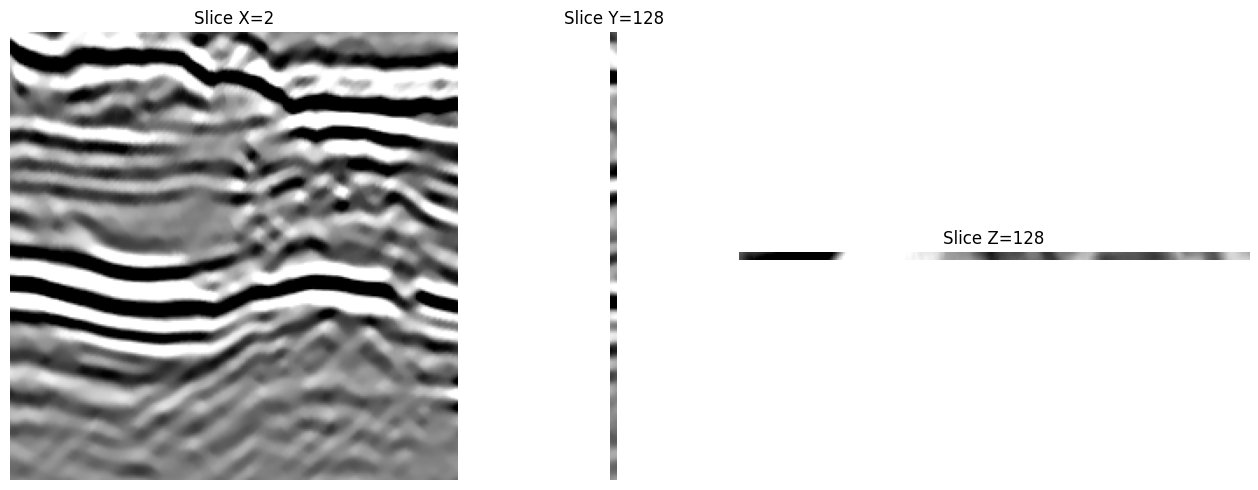

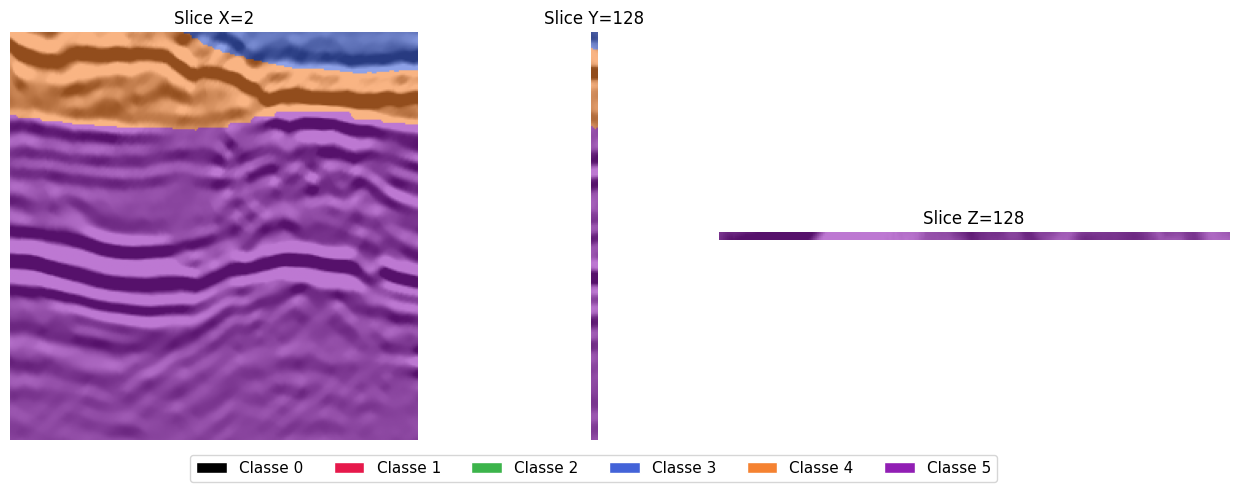

In [19]:
images, masks = next(iter(trainLoaders[0]))
img = images[0].squeeze().cpu().numpy()
msk = masks[0].squeeze().cpu().numpy()

print('xTrain Shape: ', img.shape)
print('yTrain Shape: ', msk.shape)
print('xTrain Range: ', (float(np.min(img)), float(np.max(img))))
print('yTrain Unique:', np.unique(msk).astype(int))

showTile(img)
showTile(img=img, mask=msk)

# TREINAMENTO

### Losses

In [20]:
from Losses.index import Losses
from EarlyStopping.index import EarlyStopping
from EMA.index import ModelEMA
from torch import amp
gc.collect()

7229

In [21]:
selected_loss = OPTIONS.get('loss')
loss = Losses(selected_loss, multiclass=network.multiclass)
loss

DiceFocalLoss(
  (_loss): DiceFocalLoss(
    (dice): DiceLoss()
    (focal): FocalLoss()
  )
)

### Scheduler

- `plateau`: corta o `lr` pela metade quando o `val_loss` fica 10 épocas sem melhorar, uma vez por época.
- `cosine`: a agenda dos autores da ResACEUnet — sobe linear de 1e-6 até o `lr` nas 10 primeiras épocas e desce em cosseno até 1e-7 no fim das `epochs`, andando a cada batch.

In [22]:
from torch.optim.lr_scheduler import LambdaLR
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [23]:
# AQUECIMENTO + COSSENO DA RESACEUNET (ZU ET AL. 2024, SEÇÃO 3.2): SOBE LINEAR DE 1e-6 ATÉ O lr NAS 10 PRIMEIRAS ÉPOCAS
# (warmup_epochs DO config.yaml DOS AUTORES) E DESCE EM COSSENO ATÉ 1e-7 NO FIM DAS epochs, UM PASSO POR BATCH
class CosineScheduler(LambdaLR):
    WARMUP = 10
    START  = 1e-6
    END    = 1e-7

    def __init__(self, optimizer, epochs, steps):
        self.peak   = optimizer.param_groups[0].get('initial_lr', optimizer.param_groups[0]['lr'])
        self.warmup = self.WARMUP * steps
        self.total  = epochs * steps
        super().__init__(optimizer, self.factor)

    def factor(self, step):
        if step < self.warmup:
            return (self.START + (self.peak - self.START) * step / self.warmup) / self.peak

        progress = min((step - self.warmup) / max(self.total - self.warmup, 1), 1.0)
        return (self.END + (self.peak - self.END) * 0.5 * (1.0 + math.cos(math.pi * progress))) / self.peak


class Scheduler:
    def __new__(cls, selected, optimizer, epochs=100, steps=1):
        if selected == 'plateau':
            return ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
        
        if selected == 'cosine':
            return CosineScheduler(optimizer, epochs=epochs, steps=steps)
        
        return None


scheduler = OPTIONS.get('scheduler')
Scheduler(scheduler, network.optimizer)

### Trainer

In [24]:
class Trainer:
    def __init__(self, network, loss, trainLoader, valLoader, epochs, scheduler='plateau', ema=False, fold=0, transforms=None, use_amp=False, patience=15):
        self.network  = network
        self.loss     = loss
        self.epochs   = epochs
        self.img_size = network.img_size
        self.fold     = fold

        self.trainLoader = trainLoader
        self.valLoader   = valLoader

        self.scheduler = Scheduler(scheduler, self.network.optimizer, epochs=epochs, steps=len(trainLoader))
        self.stepwise  = isinstance(self.scheduler, CosineScheduler)
        self.early_stopping = EarlyStopping(patience=patience, mode='max', min_delta=1e-4)

        # PESOS DAS CABECAS AUXILIARES QUANDO A REDE DEVOLVE LISTA (DEEP SUPERVISION), NORMALIZADOS PELA SOMA PARA O train_loss SEGUIR COMPARAVEL ENTRE EXPERIMENTOS
        self.ds_weights = [1.0, 0.5, 0.25, 0.125]

        self.use_amp = use_amp
        self.scaler  = amp.GradScaler('cuda', enabled=self.use_amp)

        # COM EMA A VALIDACAO, O EARLY STOPPING E O TESTE USAM A MEDIA DOS PESOS, NAO O MODELO VIVO
        self.ema = ModelEMA(network.model, decay=0.999) if ema else None

        # PREDIÇÃO NA JANELA DO TREINO: DIRETA NO TILE DO TAMANHO DA REDE, POR JANELA DESLIZANTE QUANDO HOUVE RECORTE
        self.transforms = transforms or Transforms()

    @property
    def model(self):
        return self.ema.model if self.ema else self.network.model

    def start(self):
        self.history = []
        
        for epoch in range(1, self.epochs + 1):
            train_loss, train_iou = self.train(self.trainLoader)
            val_loss, val_iou     = self.evaluate(self.valLoader)

            self.history.append({
                'fold': self.fold,
                'epoch': epoch,
                'train_loss': train_loss, 'val_loss': val_loss,
                'train_iou': train_iou, 'val_iou': val_iou,
                'lr': self.network.optimizer.param_groups[0]['lr'],
            })
            
            # O COSSENO JÁ ANDOU A CADA BATCH NO train(); O PLATEAU ANDA AQUI, COM O val_loss DA ÉPOCA
            if not self.stepwise:
                self.scheduler.step(val_loss)
            print(self.history[-1])

            with open(f'progress.json', 'w', encoding='utf-8') as file:
                json.dump(self.history[-1], file, ensure_ascii=False, indent=4)
            
            if self.early_stopping.ready(self.model, val_iou):
                break
            
        # O MELHOR ESTADO (DO EMA, SE LIGADO) VAI PARA O MODELO VIVO, QUE E O QUE SE SALVA E PLOTA
        self.early_stopping.restore_best(self.network.model)
        if self.ema:
            self.ema.model.load_state_dict(self.network.model.state_dict())

    # PERDA DA ITERACAO: A REDE PODE TER UM TERMO PROPRIO (A FAULT-SEG-NET SOMA O DO MSR, EQ. 12 DO ARTIGO)
    # O TERMO VEM DO MODELO QUE FEZ O FORWARD (O VIVO NO TREINO, O EMA NA AVALIACAO); COM DEEP SUPERVISION A REDE DEVOLVE LISTA
    def criterion(self, model, logits, masks):
        if isinstance(logits, (list, tuple)):
            weights = self.ds_weights[:len(logits)]
            loss    = sum(w * self.loss(o, masks) for w, o in zip(weights, logits)) / sum(weights)
        else:
            loss = self.loss(logits, masks)

        return model.compose(loss) if hasattr(model, 'compose') else loss

    def train(self, loader):
        self.network.model.train()
        self.network.iou.reset()
        train_loss = 0.0

        # SORTEIO NOVO DA AUMENTAÇÃO: OS WORKERS NASCEM A CADA ÉPOCA COM UMA CÓPIA DO DATASET JÁ COM ESTA ÉPOCA
        loader.dataset.epoch += 1

        for (imgs, masks) in loader:
            imgs, masks = imgs.to(self.network.device), masks.to(self.network.device)
            self.network.optimizer.zero_grad()

            # calcular loss
            with amp.autocast('cuda', enabled=self.use_amp):
                logits = self.network.model(imgs)
                loss = self.criterion(self.network.model, logits, masks)
                logits = logits[0] if isinstance(logits, (list, tuple)) else logits   # o iou e o da saida principal
            
            train_loss += loss.item()
            self.scaler.scale(loss).backward()

            self.scaler.unscale_(self.network.optimizer)
            torch.nn.utils.clip_grad_norm_(self.network.model.parameters(), max_norm=1.0)

            self.scaler.step(self.network.optimizer)
            self.scaler.update()

            if self.stepwise:
                self.scheduler.step()

            if self.ema:
                self.ema.update(self.network.model)
            
            # calcular iou
            if self.network.multiclass:
                preds  = torch.argmax(logits, dim=1) 
                target = masks.squeeze(1) if masks.dim() == 5 else masks
                self.network.iou.update(preds, target) 
            else:
                preds = (torch.sigmoid(logits) > 0.5)
                self.network.iou.update(preds, masks.int()) 
        
        # finalizar
        train_loss /= len(loader)
        train_iou  = self.network.iou.compute().item()
        return (train_loss, train_iou)

    def evaluate(self, loader):
        self.model.eval()
        self.network.iou.reset()
        val_loss = 0.0

        with torch.no_grad():
            for (imgs, masks) in loader:
                imgs, masks = imgs.to(self.network.device), masks.to(self.network.device)

                with amp.autocast('cuda', enabled=self.use_amp):
                    logits = self.transforms.infer(self.model, imgs)
                    val_loss += self.criterion(self.model, logits, masks).item()
                
                if self.network.multiclass:
                    preds  = torch.argmax(logits, dim=1)
                    target = masks.squeeze(1) if masks.dim() == 5 else masks
                    self.network.iou.update(preds, target)
                else:
                    preds = (torch.sigmoid(logits) > 0.5)
                    self.network.iou.update(preds, masks.int())
        
        val_loss /= len(loader)
        val_iou  = self.network.iou.compute().item()
        return (val_loss, val_iou)

### Validação cruzada

- Cada dobra treina uma rede nova, com a mesma semente (`42 + trial`): a diferença entre as dobras vem só dos dados.
- O melhor fold é o de maior `val_iou` no early stopping; só ele fica na memória e é o que se testa e salva.

In [ ]:
EMA    = bool(OPTIONS.get('ema', False))
EPOCHS = OPTIONS.get('epochs', 100)
AMP    = bool(OPTIONS.get('amp', False))
PATIENCE = OPTIONS.get('patience', 15)
results, histories, best = [], [], None

for fold, (trainLoader, valLoader) in enumerate(zip(trainLoaders, valLoaders)):
    print(f'\n----- fold {fold + 1}/{K_FOLD} -----')
    seed_everything(42 + TRIAL)
    network = ModelNetwork(**model_options)
    trainer = Trainer(network, loss, trainLoader, valLoader, epochs=EPOCHS, scheduler=scheduler, ema=EMA, fold=fold, transforms=transforms, use_amp=AMP, patience=PATIENCE)
    trainer.start()

    results.append({'fold': fold, 'train': len(trainLoader.dataset), 'val': len(valLoader.dataset), 'epochs': len(trainer.history), 'val_iou': trainer.early_stopping.best})
    histories.append(trainer.history)

    if best is None or trainer.early_stopping.best > best[2].early_stopping.best:
        best = (fold, network, trainer)

    del network, trainer
    gc.collect()
    torch.cuda.empty_cache()


----- fold 1/5 -----
random seed done


In [ ]:
FOLD, network, trainer = best
del best

DIVISION['n_images'] = {'total': len(df), 'train': len(folds[FOLD][0]), 'val': len(folds[FOLD][1]), 'test': len(test_df)}
CV_IOU = float(np.mean([result['val_iou'] for result in results]))

print(f'val_iou das dobras: {CV_IOU:.4f} ± {np.std([result["val_iou"] for result in results]):.4f} | melhor fold: {FOLD}')
pd.DataFrame(results).assign(best=lambda table: table.fold == FOLD)

In [ ]:
def plotModel(histories, best=None, save=None):
    plt.figure(figsize=(17, 5))

    for fold, history in enumerate(histories):
        width = 2.5 if fold == best else 1
        name  = f'fold {fold}' + (' (best)' if fold == best else '')

        plt.subplot(1, 2, 1)
        plt.plot([h.get('train_loss') for h in history], '--', color=f'C{fold}', lw=width, alpha=0.6, label=f'Training loss {name}')
        plt.plot([h.get('val_loss') for h in history], '-', color=f'C{fold}', lw=width, label=f'Validation loss {name}')

        plt.subplot(1, 2, 2)
        plt.plot([h.get('train_iou') for h in history], '--', color=f'C{fold}', lw=width, alpha=0.6, label=f'Training IoU {name}')
        plt.plot([h.get('val_iou') for h in history], '-', color=f'C{fold}', lw=width, label=f'Validation IoU {name}')

    plt.subplot(1, 2, 1)
    plt.title('Training and validation loss')
    plt.xlabel('epoch'), plt.ylabel('loss')
    plt.legend(fontsize=7, ncol=2), plt.grid()

    plt.subplot(1, 2, 2)
    plt.title('Training and validation IoU')
    plt.xlabel('epoch'), plt.ylabel('IoU')
    plt.legend(fontsize=7, ncol=2), plt.grid(), plt.gca().set_ylim(0, 1), plt.yticks([c/10 for c in range(11)])

    if not save:
        return plt.show()

    os.makedirs(os.path.dirname(save), exist_ok=True)
    plt.savefig(save, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()


plotModel(histories, best=FOLD)

# DADOS DE TESTE

In [ ]:
test_loss, test_iou = trainer.evaluate(testLoader)
test_iou

In [ ]:
from torchmetrics.classification import MulticlassJaccardIndex


def getClasses(network, loader, save=None):
    iou_por_classe = MulticlassJaccardIndex(num_classes=network.classes, average='none').to(network.device)
    network.model.eval()

    with torch.no_grad():
        for imgs, masks in loader:
            imgs  = imgs.to(network.device)
            masks = masks.to(network.device).squeeze(1)

            with amp.autocast('cuda', enabled=AMP):
                logits = transforms.infer(network.model, imgs)

            preds = torch.argmax(logits, dim=1)
            iou_por_classe.update(preds, masks)

    ious = iou_por_classe.compute().cpu().numpy()
    ious = {str(i): float(val) for i, val in enumerate(ious)}

    class_keys = sorted([k for k in ious.keys() if k != 'mean'], key=lambda x: int(x) if x.isdigit() else x)
    sorted_ious = {k: ious[k] for k in class_keys}
    sorted_ious.update({'mean': test_iou})

    plt.figure(figsize=(17, 6))
    Plotter(sorted_ious)

    if save:
        plt.savefig(save)
        plt.close()

    return ious


if network.multiclass:
    getClasses(network, testLoader)
    plt.show()

In [ ]:
def plotPrediction(index, dataset=testDataset, network=network, alpha=0.5, savePath=None):
    img_tensor, mask_tensor = dataset[index]
    network.model.eval()

    with torch.no_grad():
        img_batch = img_tensor.unsqueeze(0).to(network.device)
        logits = transforms.infer(network.model, img_batch)
        pred = torch.argmax(logits, dim=1).squeeze() if network.multiclass else (torch.sigmoid(logits) > 0.5).squeeze().int()

    img_np  = img_tensor.squeeze().cpu().numpy()
    mask_np = mask_tensor.squeeze().cpu().numpy()
    pred_np = pred.cpu().numpy()

    if network.multiclass:
        solid_cmap, cmap = faciesCmaps(network.classes)
        mx, my, mz = img_np.shape[0] // 2, img_np.shape[1] // 2, img_np.shape[2] // 2
        planes = lambda v: [np.array(v[mx, :, :]), np.rot90(np.array(v[:, :, mz]), -1), np.array(v[:, my, :])]
        ig, mg, pg = planes(img_np), planes(mask_np), planes(pred_np)

        fig, axes = plt.subplots(2, 3, figsize=(13, 8))
        for j in range(3):
            for r, layer in enumerate([mg, pg]):
                axes[r, j].imshow(ig[j], cmap='gray')
                axes[r, j].imshow(layer[j], cmap=cmap, vmin=0, vmax=network.classes - 1, alpha=alpha)
                axes[r, j].axis('off')

        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor=solid_cmap.colors[i], edgecolor='white', label=f'Classe {i}') for i in range(network.classes)]
        fig.legend(handles=legend_elements, loc='lower center', ncol=min(network.classes, 7), bbox_to_anchor=(0.5, 0.01), fontsize=11)

        plt.tight_layout(rect=[0, 0.05, 1, 1])
        if savePath:
            plt.savefig(savePath, bbox_inches='tight', dpi=200); plt.close(fig)
        else:
            plt.show()
        return

    imgNorm = cv2.normalize(img_np, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    imgRgb  = np.stack((imgNorm, imgNorm, imgNorm), axis=-1)
    overlay = imgRgb.copy()
    is_gt   = (mask_np > 0)
    is_pred = (pred_np > 0)
    
    inters = (is_gt & is_pred)   # Acertos / Interseção
    overlay[is_gt]   = [0, 0, 255]  # Azul para o Ground Truth (Falhas reais não detectadas)
    overlay[is_pred] = [255, 0, 0]  # Vermelho para a Predição (Falsos alarmes)
    overlay[inters]  = [0, 255, 0]  # verde onde Predição e GT convergem (Acertos)

    result = (imgRgb * (1 - alpha) + overlay * alpha).astype(np.uint8)
    showTile(img=result, save=savePath)


for i in range(min(len(testDataset), 2)):
    plotPrediction(index=i, dataset=testDataset, network=network)

# SALVANDO O MODELO

In [ ]:
from datetime import datetime
import json, inspect

In [ ]:
os.makedirs('Backup/', exist_ok=True)
files   = [f for f in os.listdir('Backup/') if f.startswith('model_')]
indexes = sorted([int(path.split('_')[-1]) for path in files]) if len(files) > 0 else [0]
index   = indexes[-1] + 1
folder  = f'Backup/model_{index}'
os.makedirs(folder, exist_ok=True)
folder

In [ ]:
iouData = getClasses(network, testLoader, save=os.path.join(folder, 'classes.png')) if network.multiclass else {'mean': test_iou}
path    = os.path.join(folder, 'predictions')
os.makedirs(path, exist_ok=True)

for i in range(min(len(testDataset), 20)):
    plotPrediction(index=i, dataset=testDataset, network=network, savePath=os.path.join(path, f'pred_{i}.png'))

In [ ]:
model_info = {
    'trainer': {
        'path': f'model_{index}',
        'loss': selected_loss,
        'scheduler': scheduler,
        'epochs': trainer.epochs,
        'batch_size': OPTIONS.get('batch_size'),
        'ema': EMA,
        'trial': TRIAL,
        'fold': FOLD,
        'folds_iou': [result['val_iou'] for result in results],
        'cv_iou': CV_IOU,
        'val_iou':  trainer.early_stopping.best,
        'test_iou': test_iou
    },
    'processing': OPTIONS,
    'division': DIVISION,
    'model': model_options,
    'iou': iouData
}

model_data = {
    'model': network.model.state_dict(),
    'optimizer': network.optimizer.state_dict(),
    'timestamp': datetime.now().strftime('%d/%m/%y %H:%M:%S'), 
    'history': trainer.history,
    'folds': histories,
}

with open(f'{folder}/info.json', 'w', encoding='utf-8') as file:
    json.dump(model_info, file, ensure_ascii=False, indent=4)   

plotModel(model_data['folds'], best=FOLD, save=os.path.join(folder, 'train.png'))
torch.save(model_data, f'{folder}/model.pth')
print('model saved in', folder)